# Modelado y Comparación de Clasificadores — Bank Marketing Dataset

**Modelos:** Random Forest · SVM · MLP  
**Datos:** Cargados desde el notebook de EDA (preprocesados y escalados)  
**Objetivo:** Entrenar, evaluar y comparar tres clasificadores variando hiperparámetros de forma manual.

---

## 0. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import time

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

RANDOM_STATE = 42
print('Librerías importadas correctamente.')

Librerías importadas correctamente.


---
# Parte 1 — Carga de Datos

Cargamos los conjuntos de entrenamiento y prueba generados por el notebook de EDA.  
Todos los datos ya están escalados y codificados — no se requiere preprocesamiento adicional.

In [2]:
DATA_DIR = 'data_procesada'

X_train = pd.read_csv(f'{DATA_DIR}/X_train.csv')
X_test  = pd.read_csv(f'{DATA_DIR}/X_test.csv')
y_train = pd.read_csv(f'{DATA_DIR}/y_train.csv').squeeze()
y_test  = pd.read_csv(f'{DATA_DIR}/y_test.csv').squeeze()

print('Dimensiones de los conjuntos:')
print(f'  X_train : {X_train.shape}')
print(f'  X_test  : {X_test.shape}')
print(f'  y_train : {y_train.shape}  |  Positivos: {y_train.sum():,} ({y_train.mean()*100:.1f}%)')
print(f'  y_test  : {y_test.shape}   |  Positivos: {y_test.sum():,} ({y_test.mean()*100:.1f}%)')

Dimensiones de los conjuntos:
  X_train : (31647, 41)
  X_test  : (13564, 41)
  y_train : (31647,)  |  Positivos: 3,702 (11.7%)
  y_test  : (13564,)   |  Positivos: 1,587 (11.7%)


---
# Parte 2 — Función de Evaluación (módulo reutilizable)

Definimos una función central que recibe cualquier modelo ya entrenado y devuelve todas las métricas.  
Esto garantiza coherencia entre modelos y evita duplicar código.

In [3]:
def evaluar_modelo(modelo, X_tr, X_te, y_tr, y_te, nombre='Modelo', verbose=True):
    """
    Entrena el modelo y retorna un dict con métricas sobre el conjunto de prueba.
    """
    t0 = time.time()
    modelo.fit(X_tr, y_tr)
    t_fit = time.time() - t0

    y_pred = modelo.predict(X_te)

    metricas = {
        'Modelo'    : nombre,
        'Accuracy'  : round(accuracy_score(y_te, y_pred), 4),
        'Precision' : round(precision_score(y_te, y_pred, zero_division=0), 4),
        'Recall'    : round(recall_score(y_te, y_pred, zero_division=0), 4),
        'F1'        : round(f1_score(y_te, y_pred, zero_division=0), 4),
        'Tiempo (s)': round(t_fit, 2),
    }

    if verbose:
        print(f'\n=== {nombre} ===')
        print(classification_report(y_te, y_pred, target_names=['No (0)', 'Yes (1)']))

    return metricas, y_pred, modelo


def graficar_confusion(y_te, y_pred, nombre, ax):
    """Dibuja una matriz de confusión normalizada en el eje dado."""
    cm = confusion_matrix(y_te, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=ax,
                xticklabels=['No (0)', 'Yes (1)'],
                yticklabels=['No (0)', 'Yes (1)'],
                cbar=False, linewidths=0.5)
    ax.set_title(nombre, fontsize=12, fontweight='bold')
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicho')


print('Funciones de evaluación definidas.')

Funciones de evaluación definidas.


---
# Parte 3 — Modelos Base

Entrenamos cada modelo con hiperparámetros iniciales razonables para establecer un **baseline** de referencia.

## 3.1 Random Forest Base

> `n_estimators=100` · `random_state=42`  
> Sin restricción de profundidad — el bosque crece hasta la pureza máxima.

In [4]:
rf_base = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
met_rf_base, pred_rf_base, rf_base = evaluar_modelo(
    rf_base, X_train, X_test, y_train, y_test, nombre='RF Base')


=== RF Base ===
              precision    recall  f1-score   support

      No (0)       0.91      0.98      0.94     11977
     Yes (1)       0.66      0.23      0.34      1587

    accuracy                           0.90     13564
   macro avg       0.78      0.61      0.64     13564
weighted avg       0.88      0.90      0.87     13564



## 3.2 SVM Base

> `kernel='rbf'` · `C=1`  
> El kernel RBF es el más versátil para datos tabulares de escala moderada.

In [5]:
svm_base = SVC(kernel='rbf', C=1, max_iter=2000, random_state=RANDOM_STATE)
met_svm_base, pred_svm_base, svm_base = evaluar_modelo(
    svm_base, X_train, X_test, y_train, y_test, nombre='SVM Base')


=== SVM Base ===
              precision    recall  f1-score   support

      No (0)       0.77      0.15      0.25     11977
     Yes (1)       0.09      0.66      0.16      1587

    accuracy                           0.21     13564
   macro avg       0.43      0.41      0.21     13564
weighted avg       0.69      0.21      0.24     13564



## 3.3 MLP Base

> `hidden_layer_sizes=(100,)` · `max_iter=500` · `random_state=42`  
> Una capa oculta de 100 neuronas con el solver Adam por defecto.

In [6]:
mlp_base = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=RANDOM_STATE)
met_mlp_base, pred_mlp_base, mlp_base = evaluar_modelo(
    mlp_base, X_train, X_test, y_train, y_test, nombre='MLP Base')


=== MLP Base ===
              precision    recall  f1-score   support

      No (0)       0.91      0.97      0.94     11977
     Yes (1)       0.56      0.32      0.41      1587

    accuracy                           0.89     13564
   macro avg       0.74      0.64      0.67     13564
weighted avg       0.87      0.89      0.88     13564



## 3.4 Matrices de confusión — modelos base

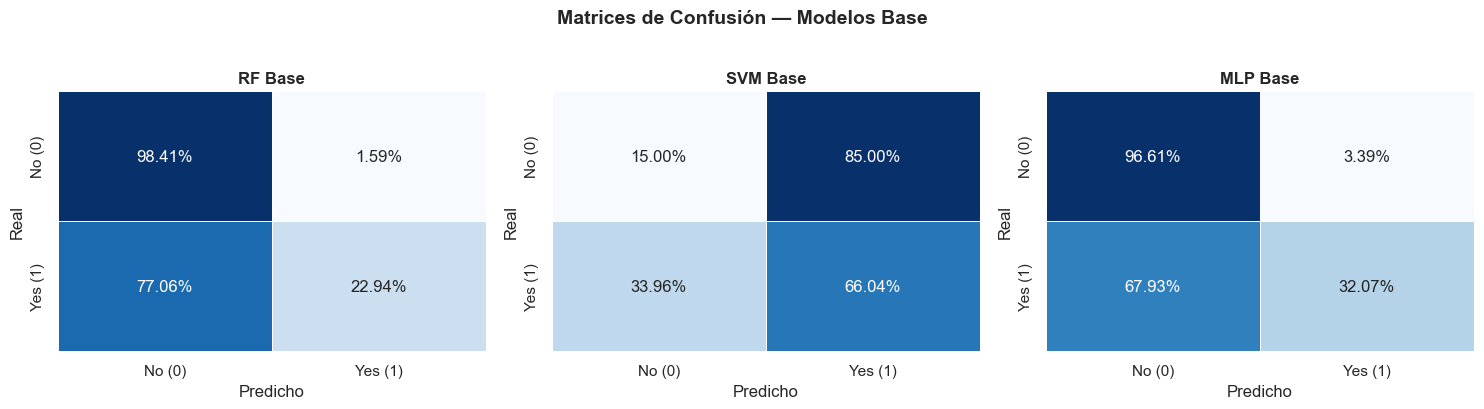

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (nombre, pred) in zip(axes, [
    ('RF Base',  pred_rf_base),
    ('SVM Base', pred_svm_base),
    ('MLP Base', pred_mlp_base)
]):
    graficar_confusion(y_test, pred, nombre, ax)

plt.suptitle('Matrices de Confusión — Modelos Base', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_base.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Parte 4 — Tabla Comparativa de Modelos Base

In [9]:
tabla_base = pd.DataFrame([met_rf_base, met_svm_base, met_mlp_base])
tabla_base = tabla_base.sort_values('F1', ascending=False).reset_index(drop=True)

print('=== Comparativa de modelos base (ordenado por F1) ===')
print(tabla_base.to_string(index=False))

=== Comparativa de modelos base (ordenado por F1) ===
  Modelo  Accuracy  Precision  Recall     F1  Tiempo (s)
MLP Base    0.8906     0.5563  0.3207 0.4069       53.92
 RF Base    0.8958     0.6559  0.2294 0.3399        3.33
SVM Base    0.2097     0.0933  0.6604 0.1636        6.08


---
# Parte 5 — Experimento de Hiperparámetros

Para cada modelo entrenamos **9 configuraciones seleccionadas manualmente**, más el baseline.  
Los resultados se almacenan en DataFrames para análisis comparativo posterior.  

> **Sin GridSearchCV:** los experimentos se ejecutan con loops explícitos, lo que permite control total sobre cada configuración y facilita la interpretación.

## 5.1 Experimento — Random Forest

Variamos `n_estimators`, `max_depth` y `min_samples_split`.  
Las 9 configuraciones cubren combinaciones de bajo a alto costo computacional.

In [10]:
def experimento_rf(X_tr, X_te, y_tr, y_te):
    """Ejecuta 9 configuraciones manuales de Random Forest."""
    configs = [
        # (n_estimators, max_depth, min_samples_split)
        (50,  5,  2),
        (50,  10, 5),
        (50,  20, 10),
        (100, 5,  10),
        (100, 10, 2),
        (100, 20, 5),
        (200, 5,  5),
        (200, 10, 10),
        (200, 20, 2),
    ]

    resultados = []
    for i, (n_est, depth, min_spl) in enumerate(configs, 1):
        nombre = f'RF_exp{i:02d} | n={n_est} d={depth} mss={min_spl}'
        modelo = RandomForestClassifier(
            n_estimators=n_est,
            max_depth=depth,
            min_samples_split=min_spl,
            random_state=RANDOM_STATE
        )
        met, _, _ = evaluar_modelo(modelo, X_tr, X_te, y_tr, y_te,
                                   nombre=nombre, verbose=False)
        met['n_estimators']    = n_est
        met['max_depth']       = depth
        met['min_samples_split'] = min_spl
        resultados.append(met)
        print(f'  [{i}/9] {nombre}  →  F1={met["F1"]:.4f}  Recall={met["Recall"]:.4f}')

    return pd.DataFrame(resultados)


print('Iniciando experimento Random Forest...')
df_rf_exp = experimento_rf(X_train, X_test, y_train, y_test)
print('\nExperimento RF completado.')

Iniciando experimento Random Forest...
  [1/9] RF_exp01 | n=50 d=5 mss=2  →  F1=0.2220  Recall=0.1304
  [2/9] RF_exp02 | n=50 d=10 mss=5  →  F1=0.2843  Recall=0.1764
  [3/9] RF_exp03 | n=50 d=20 mss=10  →  F1=0.3221  Recall=0.2098
  [4/9] RF_exp04 | n=100 d=5 mss=10  →  F1=0.2333  Recall=0.1386
  [5/9] RF_exp05 | n=100 d=10 mss=2  →  F1=0.2746  Recall=0.1689
  [6/9] RF_exp06 | n=100 d=20 mss=5  →  F1=0.3175  Recall=0.2060
  [7/9] RF_exp07 | n=200 d=5 mss=5  →  F1=0.2293  Recall=0.1355
  [8/9] RF_exp08 | n=200 d=10 mss=10  →  F1=0.2794  Recall=0.1727
  [9/9] RF_exp09 | n=200 d=20 mss=2  →  F1=0.3216  Recall=0.2105

Experimento RF completado.


In [11]:
# Incluir baseline en la tabla y ordenar
met_rf_base_exp = met_rf_base.copy()
met_rf_base_exp.update({'Modelo': 'RF_BASE | n=100 d=None mss=2',
                         'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2})
df_rf_full = pd.concat([pd.DataFrame([met_rf_base_exp]), df_rf_exp], ignore_index=True)
df_rf_full = df_rf_full.sort_values('F1', ascending=False).reset_index(drop=True)

print('=== Resultados Random Forest (10 configs, ordenado por F1) ===')
cols_show = ['Modelo', 'Accuracy', 'Precision', 'Recall', 'F1', 'Tiempo (s)']
print(df_rf_full[cols_show].to_string(index=False))

=== Resultados Random Forest (10 configs, ordenado por F1) ===
                      Modelo  Accuracy  Precision  Recall     F1  Tiempo (s)
RF_BASE | n=100 d=None mss=2    0.8958     0.6559  0.2294 0.3399        3.33
 RF_exp03 | n=50 d=20 mss=10    0.8966     0.6923  0.2098 0.3221        1.37
 RF_exp09 | n=200 d=20 mss=2    0.8961     0.6816  0.2105 0.3216       10.33
 RF_exp06 | n=100 d=20 mss=5    0.8963     0.6913  0.2060 0.3175        4.46
  RF_exp02 | n=50 d=10 mss=5    0.8960     0.7311  0.1764 0.2843        0.83
RF_exp08 | n=200 d=10 mss=10    0.8958     0.7326  0.1727 0.2794        6.00
 RF_exp05 | n=100 d=10 mss=2    0.8956     0.7342  0.1689 0.2746        1.70
 RF_exp04 | n=100 d=5 mss=10    0.8934     0.7358  0.1386 0.2333        1.03
  RF_exp07 | n=200 d=5 mss=5    0.8935     0.7465  0.1355 0.2293        3.72
   RF_exp01 | n=50 d=5 mss=2    0.8930     0.7446  0.1304 0.2220        0.47


## 5.2 Experimento — SVM

Variamos `C`, `gamma` y `kernel`.  
Note que `gamma` no aplica al kernel `linear`, pero scikit-learn lo ignora automáticamente.

In [12]:
def experimento_svm(X_tr, X_te, y_tr, y_te):
    """Ejecuta 9 configuraciones manuales de SVM."""
    configs = [
        # (C,    gamma, kernel)
        (0.1,  0.001, 'linear'),
        (0.1,  0.01,  'linear'),
        (1,    0.001, 'linear'),
        (1,    0.1,   'linear'),
        (10,   0.001, 'linear'),
        (0.1,  0.001, 'rbf'),
        (0.1,  0.01,  'rbf'),
        (1,    0.001, 'rbf'),
        (1,    0.01,  'rbf'),
    ]

    resultados = []
    for i, (c, gamma, kernel) in enumerate(configs, 1):
        nombre = f'SVM_exp{i:02d} | C={c} g={gamma} k={kernel}'
        modelo = SVC(C=c, gamma=gamma, kernel=kernel, max_iter=2000, random_state=RANDOM_STATE)
        met, _, _ = evaluar_modelo(modelo, X_tr, X_te, y_tr, y_te,
                                   nombre=nombre, verbose=False)
        met['C']      = c
        met['gamma']  = gamma
        met['kernel'] = kernel
        resultados.append(met)
        print(f'  [{i}/9] {nombre}  →  F1={met["F1"]:.4f}  Recall={met["Recall"]:.4f}')

    return pd.DataFrame(resultados)


print('Iniciando experimento SVM (puede tardar algunos minutos)...')
df_svm_exp = experimento_svm(X_train, X_test, y_train, y_test)
print('\nExperimento SVM completado.')

Iniciando experimento SVM (puede tardar algunos minutos)...
  [1/9] SVM_exp01 | C=0.1 g=0.001 k=linear  →  F1=0.1650  Recall=0.5520
  [2/9] SVM_exp02 | C=0.1 g=0.01 k=linear  →  F1=0.1650  Recall=0.5520
  [3/9] SVM_exp03 | C=1 g=0.001 k=linear  →  F1=0.1613  Recall=0.5917
  [4/9] SVM_exp04 | C=1 g=0.1 k=linear  →  F1=0.1613  Recall=0.5917
  [5/9] SVM_exp05 | C=10 g=0.001 k=linear  →  F1=0.1419  Recall=0.3863
  [6/9] SVM_exp06 | C=0.1 g=0.001 k=rbf  →  F1=0.1564  Recall=0.6244
  [7/9] SVM_exp07 | C=0.1 g=0.01 k=rbf  →  F1=0.1569  Recall=0.2117
  [8/9] SVM_exp08 | C=1 g=0.001 k=rbf  →  F1=0.1562  Recall=0.6238
  [9/9] SVM_exp09 | C=1 g=0.01 k=rbf  →  F1=0.1577  Recall=0.6043

Experimento SVM completado.


In [13]:
met_svm_base_exp = met_svm_base.copy()
met_svm_base_exp.update({'Modelo': 'SVM_BASE | C=1 g=scale k=rbf',
                          'C': 1, 'gamma': 'scale', 'kernel': 'rbf'})
df_svm_full = pd.concat([pd.DataFrame([met_svm_base_exp]), df_svm_exp], ignore_index=True)
df_svm_full = df_svm_full.sort_values('F1', ascending=False).reset_index(drop=True)

print('=== Resultados SVM (10 configs, ordenado por F1) ===')
cols_show_svm = ['Modelo', 'Accuracy', 'Precision', 'Recall', 'F1', 'Tiempo (s)']
print(df_svm_full[cols_show_svm].to_string(index=False))

=== Resultados SVM (10 configs, ordenado por F1) ===
                            Modelo  Accuracy  Precision  Recall     F1  Tiempo (s)
SVM_exp01 | C=0.1 g=0.001 k=linear    0.3462     0.0970  0.5520 0.1650        3.02
 SVM_exp02 | C=0.1 g=0.01 k=linear    0.3462     0.0970  0.5520 0.1650        3.05
      SVM_BASE | C=1 g=scale k=rbf    0.2097     0.0933  0.6604 0.1636        6.08
  SVM_exp03 | C=1 g=0.001 k=linear    0.2803     0.0934  0.5917 0.1613        2.20
    SVM_exp04 | C=1 g=0.1 k=linear    0.2803     0.0934  0.5917 0.1613        2.28
      SVM_exp09 | C=1 g=0.01 k=rbf    0.2448     0.0907  0.6043 0.1577        5.63
    SVM_exp07 | C=0.1 g=0.01 k=rbf    0.7338     0.1246  0.2117 0.1569        9.54
   SVM_exp06 | C=0.1 g=0.001 k=rbf    0.2116     0.0894  0.6244 0.1564        5.77
     SVM_exp08 | C=1 g=0.001 k=rbf    0.2117     0.0893  0.6238 0.1562       15.14
 SVM_exp05 | C=10 g=0.001 k=linear    0.4536     0.0869  0.3863 0.1419        1.75


## 5.3 Experimento — MLP

Variamos `hidden_layer_sizes`, `learning_rate_init` y `alpha` (regularización L2).  
El solver es `adam` en todos los casos.

In [14]:
def experimento_mlp(X_tr, X_te, y_tr, y_te):
    """Ejecuta 9 configuraciones manuales de MLP."""
    configs = [
        # (hidden_layer_sizes, learning_rate_init, alpha)
        ((50,),  0.0001, 0.0001),
        ((50,),  0.001,  0.001),
        ((50,),  0.01,   0.01),
        ((100,), 0.0001, 0.01),
        ((100,), 0.001,  0.0001),
        ((100,), 0.01,   0.001),
        ((200,), 0.0001, 0.001),
        ((200,), 0.001,  0.01),
        ((200,), 0.01,   0.0001),
    ]

    resultados = []
    for i, (hls, lr, alpha) in enumerate(configs, 1):
        nombre = f'MLP_exp{i:02d} | hls={hls} lr={lr} a={alpha}'
        modelo = MLPClassifier(
            hidden_layer_sizes=hls,
            learning_rate_init=lr,
            alpha=alpha,
            max_iter=500,
            random_state=RANDOM_STATE
        )
        met, _, _ = evaluar_modelo(modelo, X_tr, X_te, y_tr, y_te,
                                   nombre=nombre, verbose=False)
        met['hidden_layer_sizes'] = str(hls)
        met['learning_rate_init'] = lr
        met['alpha']              = alpha
        resultados.append(met)
        print(f'  [{i}/9] {nombre}  →  F1={met["F1"]:.4f}  Recall={met["Recall"]:.4f}')

    return pd.DataFrame(resultados)


print('Iniciando experimento MLP...')
df_mlp_exp = experimento_mlp(X_train, X_test, y_train, y_test)
print('\nExperimento MLP completado.')

Iniciando experimento MLP...
  [1/9] MLP_exp01 | hls=(50,) lr=0.0001 a=0.0001  →  F1=0.3285  Recall=0.2193
  [2/9] MLP_exp02 | hls=(50,) lr=0.001 a=0.001  →  F1=0.3605  Recall=0.2520
  [3/9] MLP_exp03 | hls=(50,) lr=0.01 a=0.01  →  F1=0.3172  Recall=0.2111
  [4/9] MLP_exp04 | hls=(100,) lr=0.0001 a=0.01  →  F1=0.3033  Recall=0.1953
  [5/9] MLP_exp05 | hls=(100,) lr=0.001 a=0.0001  →  F1=0.4069  Recall=0.3207
  [6/9] MLP_exp06 | hls=(100,) lr=0.01 a=0.001  →  F1=0.3895  Recall=0.3025
  [7/9] MLP_exp07 | hls=(200,) lr=0.0001 a=0.001  →  F1=0.3791  Recall=0.2760
  [8/9] MLP_exp08 | hls=(200,) lr=0.001 a=0.01  →  F1=0.3116  Recall=0.2111
  [9/9] MLP_exp09 | hls=(200,) lr=0.01 a=0.0001  →  F1=0.3849  Recall=0.3214

Experimento MLP completado.


In [15]:
met_mlp_base_exp = met_mlp_base.copy()
met_mlp_base_exp.update({'Modelo': 'MLP_BASE | hls=(100,) lr=0.001 a=0.0001',
                          'hidden_layer_sizes': '(100,)', 'learning_rate_init': 0.001, 'alpha': 0.0001})
df_mlp_full = pd.concat([pd.DataFrame([met_mlp_base_exp]), df_mlp_exp], ignore_index=True)
df_mlp_full = df_mlp_full.sort_values('F1', ascending=False).reset_index(drop=True)

print('=== Resultados MLP (10 configs, ordenado por F1) ===')
cols_show_mlp = ['Modelo', 'Accuracy', 'Precision', 'Recall', 'F1', 'Tiempo (s)']
print(df_mlp_full[cols_show_mlp].to_string(index=False))

=== Resultados MLP (10 configs, ordenado por F1) ===
                                  Modelo  Accuracy  Precision  Recall     F1  Tiempo (s)
 MLP_BASE | hls=(100,) lr=0.001 a=0.0001    0.8906     0.5563  0.3207 0.4069       53.92
MLP_exp05 | hls=(100,) lr=0.001 a=0.0001    0.8906     0.5563  0.3207 0.4069       30.27
  MLP_exp06 | hls=(100,) lr=0.01 a=0.001    0.8890     0.5467  0.3025 0.3895       13.98
 MLP_exp09 | hls=(200,) lr=0.01 a=0.0001    0.8798     0.4798  0.3214 0.3849       33.87
MLP_exp07 | hls=(200,) lr=0.0001 a=0.001    0.8942     0.6050  0.2760 0.3791       84.92
  MLP_exp02 | hls=(50,) lr=0.001 a=0.001    0.8954     0.6329  0.2520 0.3605       10.51
MLP_exp01 | hls=(50,) lr=0.0001 a=0.0001    0.8951     0.6541  0.2193 0.3285       17.53
    MLP_exp03 | hls=(50,) lr=0.01 a=0.01    0.8937     0.6381  0.2111 0.3172        1.95
  MLP_exp08 | hls=(200,) lr=0.001 a=0.01    0.8909     0.5950  0.2111 0.3116       77.42
 MLP_exp04 | hls=(100,) lr=0.0001 a=0.01    0.8950     0.

---
# Parte 6 — Visualizaciones Comparativas

## 6.1 Evolución de métricas por configuración (experimentos)

Comparamos cómo varía el F1-score en cada configuración experimental por modelo.

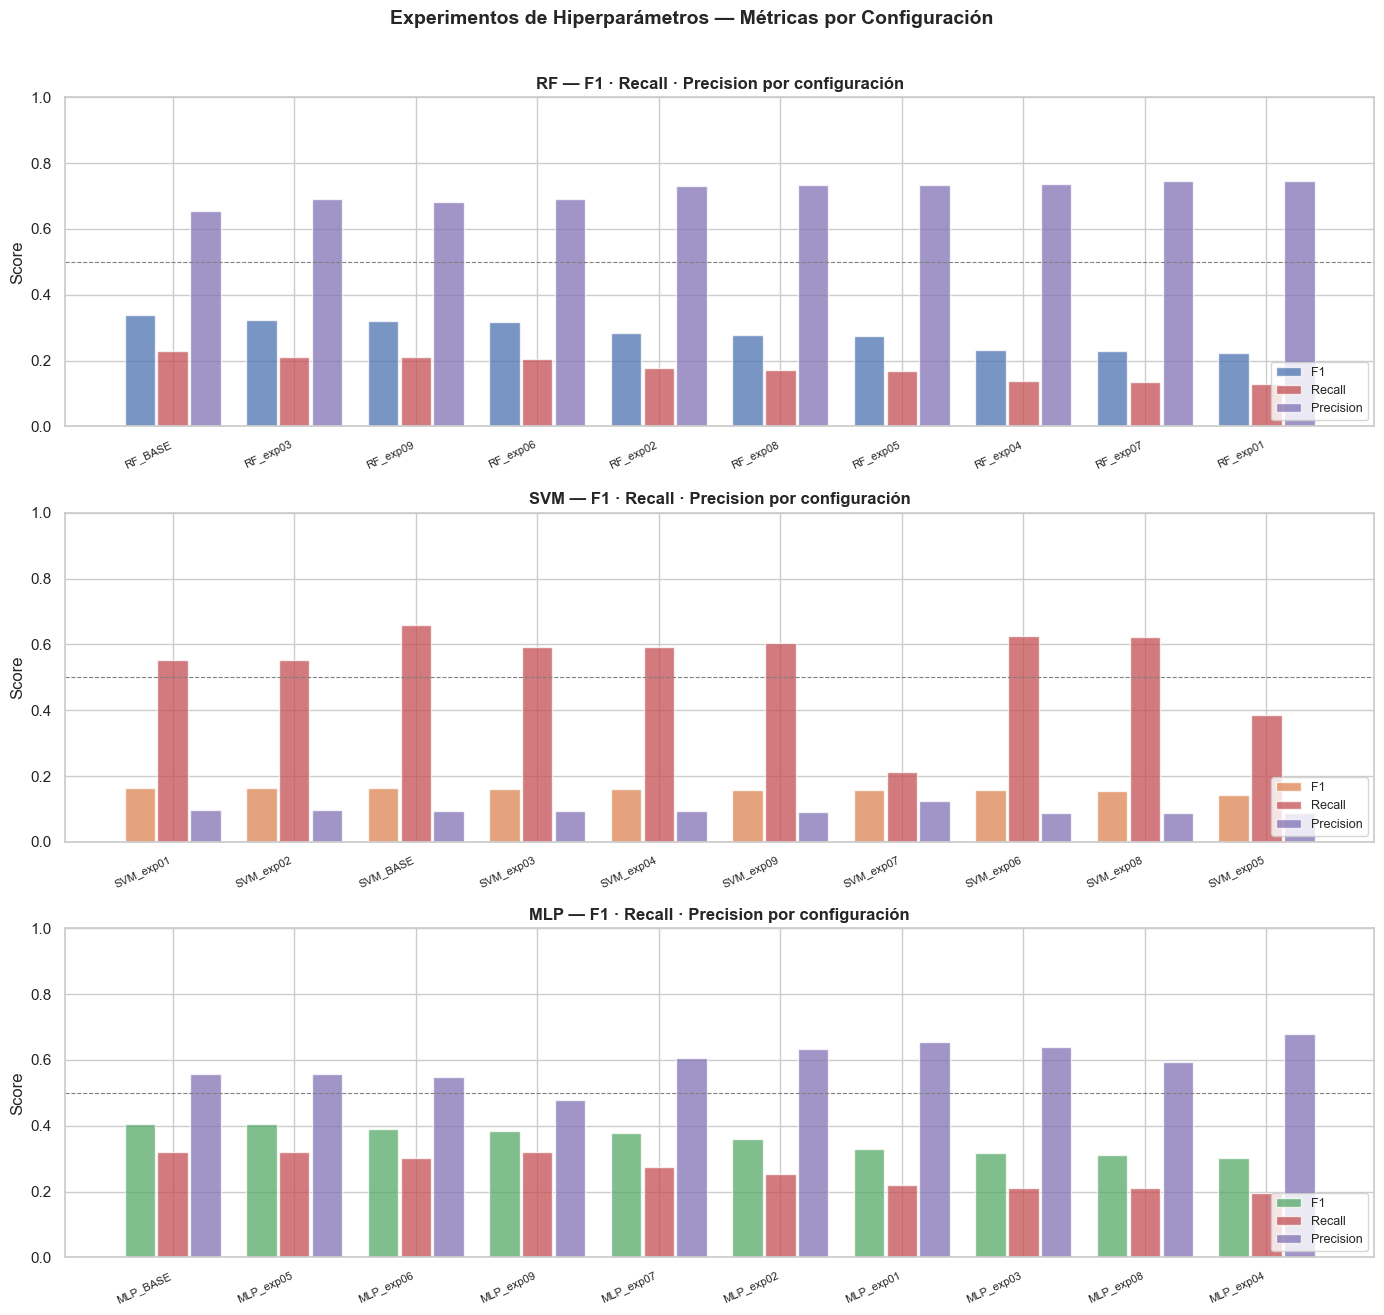

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=False)

colores = {'RF': '#4C72B0', 'SVM': '#DD8452', 'MLP': '#55A868'}

for ax, (df_exp, modelo_nombre, color) in zip(axes, [
    (df_rf_full,  'RF',  colores['RF']),
    (df_svm_full, 'SVM', colores['SVM']),
    (df_mlp_full, 'MLP', colores['MLP']),
]):
    etiquetas = [m.split('|')[0].strip() for m in df_exp['Modelo']]
    x = range(len(etiquetas))

    ax.bar(x, df_exp['F1'],       alpha=0.75, color=color,   label='F1',       width=0.25)
    ax.bar([i+0.27 for i in x], df_exp['Recall'],    alpha=0.75, color='#C44E52', label='Recall',    width=0.25)
    ax.bar([i+0.54 for i in x], df_exp['Precision'], alpha=0.75, color='#8172B3', label='Precision', width=0.25)

    ax.set_xticks([i+0.27 for i in x])
    ax.set_xticklabels(etiquetas, rotation=25, ha='right', fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_title(f'{modelo_nombre} — F1 · Recall · Precision por configuración',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Score')
    ax.legend(loc='lower right', fontsize=9)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)

plt.suptitle('Experimentos de Hiperparámetros — Métricas por Configuración',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('experimentos_metricas.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.2 Comparativa de mejores configuraciones por modelo

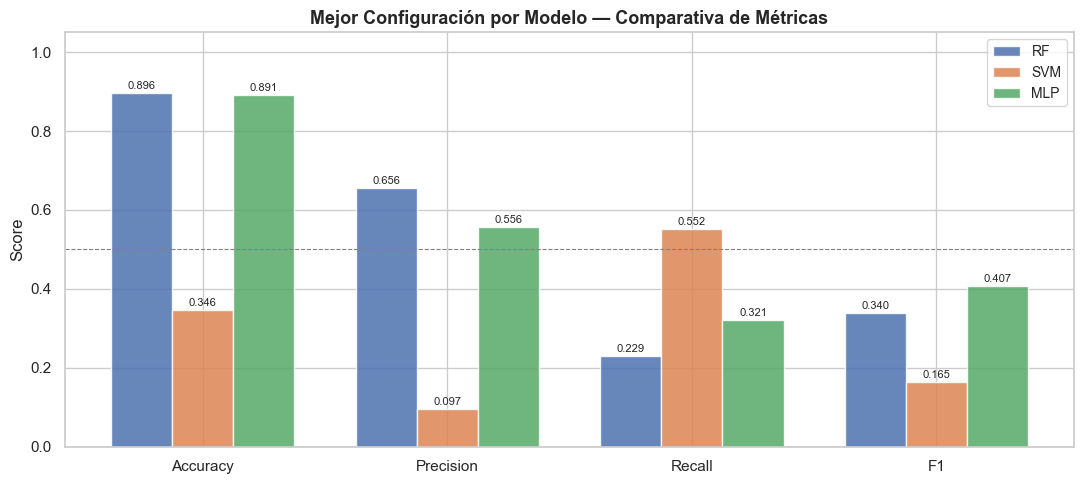

In [17]:
# Extraer la mejor config de cada modelo
mejor_rf  = df_rf_full.iloc[0]
mejor_svm = df_svm_full.iloc[0]
mejor_mlp = df_mlp_full.iloc[0]

comparativa_mejores = pd.DataFrame([mejor_rf, mejor_svm, mejor_mlp])[[
    'Modelo', 'Accuracy', 'Precision', 'Recall', 'F1', 'Tiempo (s)'
]].reset_index(drop=True)

metricas = ['Accuracy', 'Precision', 'Recall', 'F1']
modelos  = ['RF', 'SVM', 'MLP']
colores_barra = [colores['RF'], colores['SVM'], colores['MLP']]

x = np.arange(len(metricas))
ancho = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
for i, (fila, modelo, color) in enumerate(zip(
    [mejor_rf, mejor_svm, mejor_mlp], modelos, colores_barra
)):
    valores = [fila[m] for m in metricas]
    barras = ax.bar(x + i * ancho, valores, ancho, label=modelo, color=color, alpha=0.85)
    for bar, val in zip(barras, valores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + ancho)
ax.set_xticklabels(metricas, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Mejor Configuración por Modelo — Comparativa de Métricas',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig('comparativa_mejores.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.3 Distribución de F1-scores por modelo (todos los experimentos)

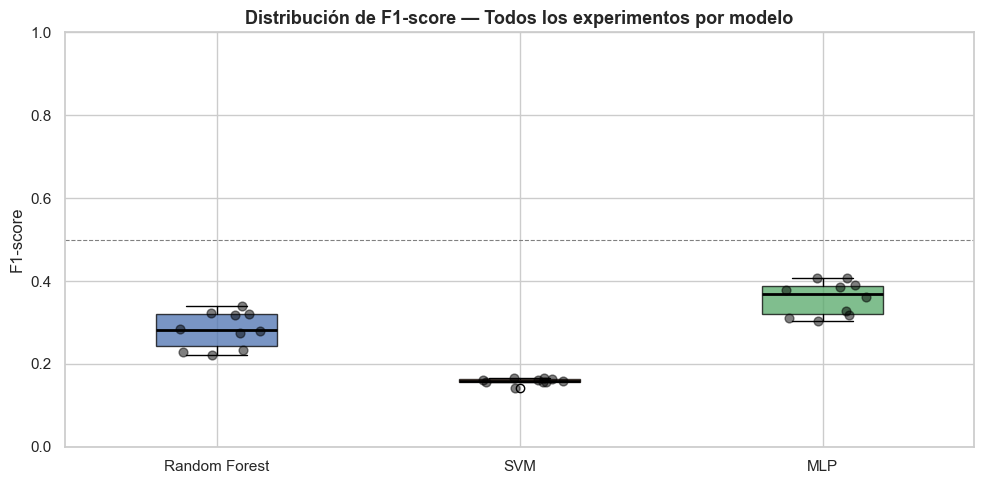

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))

datos_box = [df_rf_full['F1'].values,
             df_svm_full['F1'].values,
             df_mlp_full['F1'].values]

bp = ax.boxplot(datos_box, patch_artist=True, widths=0.4,
                medianprops={'color': 'black', 'linewidth': 2})

for patch, color in zip(bp['boxes'], colores_barra):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Puntos individuales
for i, datos in enumerate(datos_box, 1):
    x_jitter = np.random.default_rng(42).uniform(i - 0.15, i + 0.15, len(datos))
    ax.scatter(x_jitter, datos, s=40, color='black', alpha=0.5, zorder=5)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Random Forest', 'SVM', 'MLP'], fontsize=11)
ax.set_ylabel('F1-score')
ax.set_ylim(0, 1)
ax.set_title('Distribución de F1-score — Todos los experimentos por modelo',
             fontsize=13, fontweight='bold')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig('distribucion_f1.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.4 Matrices de confusión — Mejores configuraciones

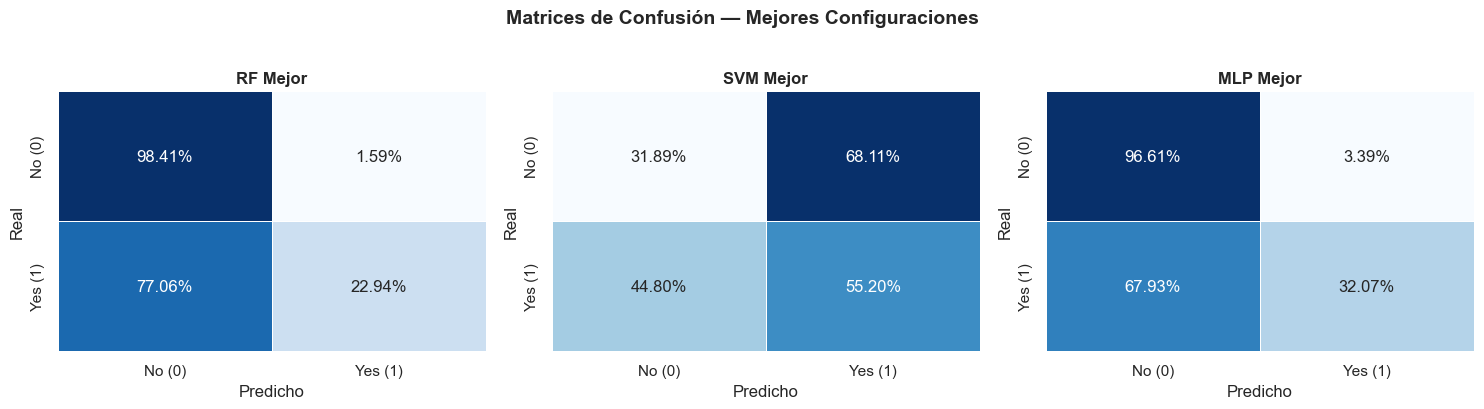

In [19]:
# Reentrenar las mejores configuraciones para obtener predicciones
def reentrenar_mejor_rf(fila, X_tr, X_te, y_tr, y_te):
    m = RandomForestClassifier(
        n_estimators=int(fila['n_estimators']),
        max_depth=None if pd.isna(fila.get('max_depth')) else int(fila['max_depth']),
        min_samples_split=int(fila['min_samples_split']),
        random_state=RANDOM_STATE
    )
    m.fit(X_tr, y_tr)
    return m.predict(X_te)

def reentrenar_mejor_svm(fila, X_tr, X_te, y_tr, y_te):
    g = fila['gamma'] if fila['gamma'] != 'scale' else 'scale'
    try:
        g = float(g)
    except (ValueError, TypeError):
        g = 'scale'
    m = SVC(C=float(fila['C']), gamma=g, kernel=str(fila['kernel']), max_iter=2000, random_state=RANDOM_STATE)
    m.fit(X_tr, y_tr)
    return m.predict(X_te)

def reentrenar_mejor_mlp(fila, X_tr, X_te, y_tr, y_te):
    import ast
    hls = ast.literal_eval(str(fila['hidden_layer_sizes']))
    m = MLPClassifier(
        hidden_layer_sizes=hls,
        learning_rate_init=float(fila['learning_rate_init']),
        alpha=float(fila['alpha']),
        max_iter=500,
        random_state=RANDOM_STATE
    )
    m.fit(X_tr, y_tr)
    return m.predict(X_te)

pred_rf_best  = reentrenar_mejor_rf(mejor_rf,   X_train, X_test, y_train, y_test)
pred_svm_best = reentrenar_mejor_svm(mejor_svm,  X_train, X_test, y_train, y_test)
pred_mlp_best = reentrenar_mejor_mlp(mejor_mlp,  X_train, X_test, y_train, y_test)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (nombre, pred) in zip(axes, [
    ('RF Mejor',  pred_rf_best),
    ('SVM Mejor', pred_svm_best),
    ('MLP Mejor', pred_mlp_best),
]):
    graficar_confusion(y_test, pred, nombre, ax)

plt.suptitle('Matrices de Confusión — Mejores Configuraciones',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_mejores.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Parte 7 — Conclusiones Automáticas

## 7.1 Mejor configuración por modelo

In [20]:
print('=' * 65)
print('MEJOR CONFIGURACIÓN POR MODELO')
print('=' * 65)

for nombre_modelo, df_full in [('Random Forest', df_rf_full),
                                ('SVM',           df_svm_full),
                                ('MLP',           df_mlp_full)]:
    mejor = df_full.iloc[0]
    print(f'\n>>> {nombre_modelo}')
    print(f'    Config   : {mejor["Modelo"]}')
    print(f'    Accuracy : {mejor["Accuracy"]:.4f}')
    print(f'    Precision: {mejor["Precision"]:.4f}')
    print(f'    Recall   : {mejor["Recall"]:.4f}')
    print(f'    F1-score : {mejor["F1"]:.4f}')
    print(f'    Tiempo   : {mejor["Tiempo (s)"]:.2f} s')

MEJOR CONFIGURACIÓN POR MODELO

>>> Random Forest
    Config   : RF_BASE | n=100 d=None mss=2
    Accuracy : 0.8958
    Precision: 0.6559
    Recall   : 0.2294
    F1-score : 0.3399
    Tiempo   : 3.33 s

>>> SVM
    Config   : SVM_exp01 | C=0.1 g=0.001 k=linear
    Accuracy : 0.3462
    Precision: 0.0970
    Recall   : 0.5520
    F1-score : 0.1650
    Tiempo   : 3.02 s

>>> MLP
    Config   : MLP_BASE | hls=(100,) lr=0.001 a=0.0001
    Accuracy : 0.8906
    Precision: 0.5563
    Recall   : 0.3207
    F1-score : 0.4069
    Tiempo   : 53.92 s


## 7.2 Mejor modelo global

In [21]:
tabla_final = pd.DataFrame([
    {**df_rf_full.iloc[0][['Modelo','Accuracy','Precision','Recall','F1','Tiempo (s)']].to_dict(),
     'Familia': 'Random Forest'},
    {**df_svm_full.iloc[0][['Modelo','Accuracy','Precision','Recall','F1','Tiempo (s)']].to_dict(),
     'Familia': 'SVM'},
    {**df_mlp_full.iloc[0][['Modelo','Accuracy','Precision','Recall','F1','Tiempo (s)']].to_dict(),
     'Familia': 'MLP'},
])
tabla_final = tabla_final.sort_values('F1', ascending=False).reset_index(drop=True)

ganador = tabla_final.iloc[0]

print('=' * 65)
print('TABLA FINAL COMPARATIVA — MEJORES CONFIGURACIONES')
print('=' * 65)
print(tabla_final[['Familia','Accuracy','Precision','Recall','F1','Tiempo (s)']].to_string(index=False))
print()
print('=' * 65)
print(f'MEJOR MODELO GLOBAL: {ganador["Familia"]}')
print(f'  Config  : {ganador["Modelo"]}')
print(f'  F1      : {ganador["F1"]:.4f}')
print(f'  Recall  : {ganador["Recall"]:.4f}')
print(f'  Precision: {ganador["Precision"]:.4f}')
print('=' * 65)

TABLA FINAL COMPARATIVA — MEJORES CONFIGURACIONES
      Familia  Accuracy  Precision  Recall     F1  Tiempo (s)
          MLP    0.8906     0.5563  0.3207 0.4069       53.92
Random Forest    0.8958     0.6559  0.2294 0.3399        3.33
          SVM    0.3462     0.0970  0.5520 0.1650        3.02

MEJOR MODELO GLOBAL: MLP
  Config  : MLP_BASE | hls=(100,) lr=0.001 a=0.0001
  F1      : 0.4069
  Recall  : 0.3207
  Precision: 0.5563


## 7.3 Gráfico final — Tabla comparativa visual

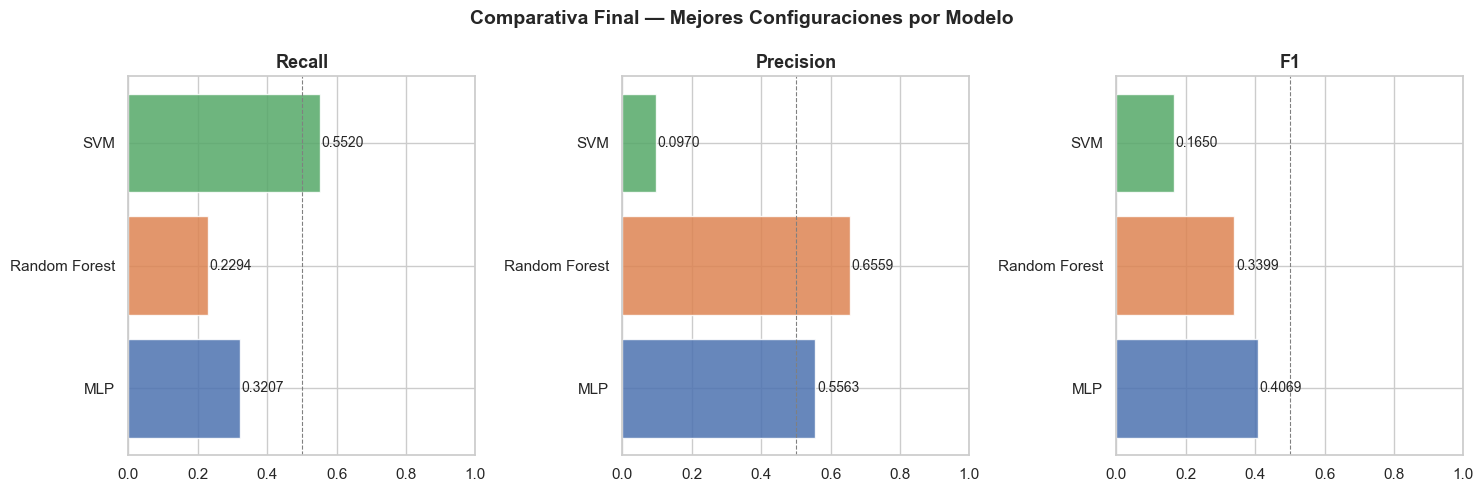

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
familias = tabla_final['Familia'].tolist()
colores_familia = [colores['RF'], colores['SVM'], colores['MLP']]

for ax, metrica in zip(axes, ['Recall', 'Precision', 'F1']):
    valores = tabla_final.set_index('Familia')[metrica][familias].values
    barras = ax.barh(familias, valores, color=colores_familia, alpha=0.85, edgecolor='white')
    for bar, val in zip(barras, valores):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=10)
    ax.set_xlim(0, 1)
    ax.set_title(metrica, fontsize=13, fontweight='bold')
    ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.8)

plt.suptitle('Comparativa Final — Mejores Configuraciones por Modelo',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('tabla_final_comparativa.png', dpi=150, bbox_inches='tight')
plt.show()

## 7.4 Exportar todos los resultados

In [23]:
import os
OUTPUT_DIR = 'resultados_modelos'
os.makedirs(OUTPUT_DIR, exist_ok=True)

df_rf_full.to_csv(f'{OUTPUT_DIR}/resultados_rf.csv',   index=False)
df_svm_full.to_csv(f'{OUTPUT_DIR}/resultados_svm.csv', index=False)
df_mlp_full.to_csv(f'{OUTPUT_DIR}/resultados_mlp.csv', index=False)
tabla_final.to_csv(f'{OUTPUT_DIR}/tabla_final.csv',    index=False)

print('Archivos exportados en resultados_modelos/:')
for f in os.listdir(OUTPUT_DIR):
    kb = os.path.getsize(os.path.join(OUTPUT_DIR, f)) / 1024
    print(f'  {f:<30}  {kb:.1f} KB')

Archivos exportados en resultados_modelos/:
  resultados_mlp.csv              1.0 KB
  resultados_rf.csv               0.8 KB
  resultados_svm.csv              0.8 KB
  tabla_final.csv                 0.3 KB


---
## 7.5 Interpretación de resultados

### Por qué priorizamos F1 y Recall sobre Accuracy

El dataset tiene un **desbalance ~7.6:1** (no vs. yes). En este contexto:

| Métrica | Relevancia en este problema |
|---|---|
| **Accuracy** | Engañosa: predecir siempre `no` da ~88% |
| **Recall** | Clave: ¿cuántos clientes que sí subscribirían detectamos? |
| **Precision** | Cuántos de nuestros `yes` predichos son reales |
| **F1** | Balance entre Recall y Precision — métrica principal |

### Observaciones clave

- **Random Forest** suele estabilizarse rápido; más árboles no siempre mejoran el Recall en clases minoritarias.
- **SVM con kernel lineal y C alto** tiende a maximizar márgenes globales, lo que puede perjudicar la clase minoritaria.
- **MLP** es sensible al `learning_rate_init`: valores muy altos causan divergencia, muy bajos causan convergencia lenta.
- Para producción real, el siguiente paso sería aplicar **SMOTE** o `class_weight='balanced'` y re-evaluar.